In [1]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences import base as sequences
from edes.experiments.sequences import calibration

from edes.experiments.devices.base import Instrument
from edes.modules.variable_attenuator import var_attn_utils
from edes.utils.file_handling import load_latest_data
from edes.utils.utils import beep_jupyter, U2_to_MHz
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
exp = Experiment('3layer_trapping_072326')

>>> ERROR connecting to RigolDG4062 at TCPIP::192.168.169.104::INSTR: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.
>>> ERROR initializing device AWG: 'RigolDG4062' object has no attribute 'instrument'
>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to ARTIQ Zotino.
>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> ERROR connecting to Keithley2100 at USB0::1510::8448::1243106::0::INSTR: No device found.
>>> Connected to Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3773,1.01.01.02.07R2,V3.0

>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> Connected to Valon at ASRL/dev/ttyUSB0::INSTR with frequency 1465200000 Hz and power 0 dBm.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


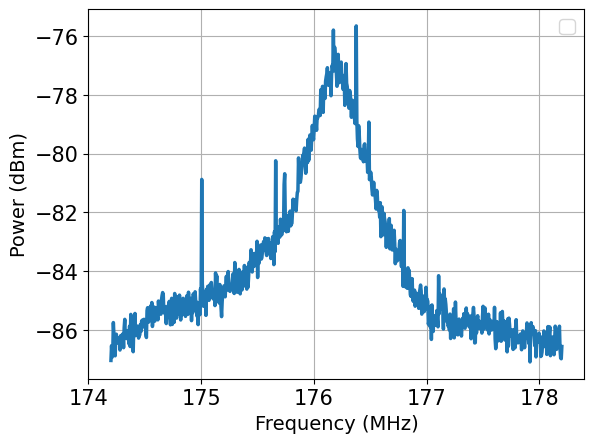

In [4]:
exp.SSA.select_mode('SA')
exp.SSA.set_N_avg(64)
exp.SSA.set_freq_span(4e6)
exp.SSA.set_freq_center(176.200e6)
exp.SSA.set_div_scale(1)
# exp.SSA.set_SWT(100e-3)
exp.SSA.set_RBW(1e3)
exp.SSA.set_VBW(1e3)
exp.SSA.set_ref_level(-68)
freq, data = exp.SSA.measure_freq_spectrum()
plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')
# plt.axvline(175, linestyle='--', color='r', alpha=0.7, label=f'Urukul applied to tickle line\n70+15dB attenuation\nmeasured {data[np.argmin(abs(freq-175e6))]:.1f}dB')
plt.legend()

In [7]:
exp.FEtip_PSU.set_voltage(0)

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


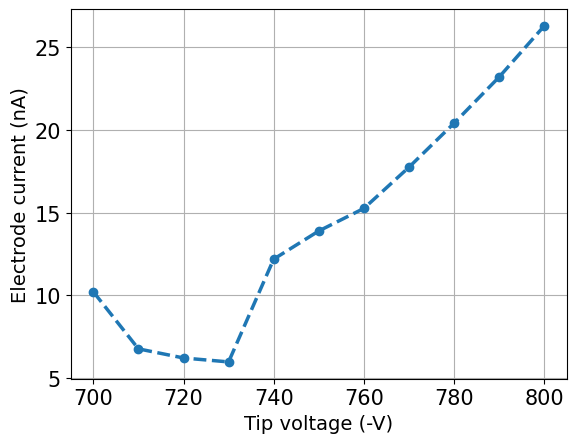

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


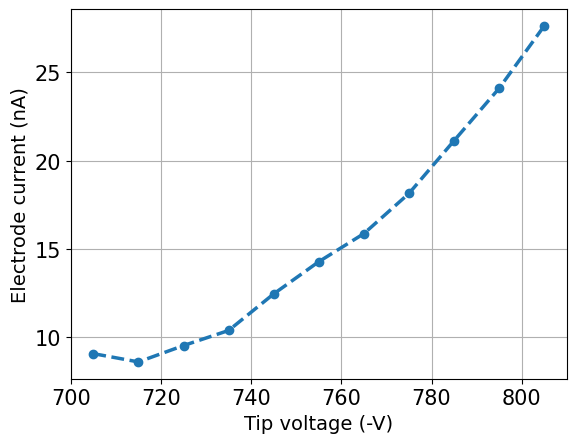

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


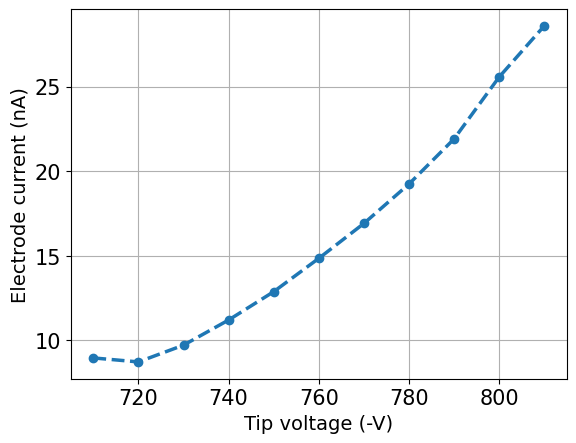

100%|███████████████████████████████████████████| 11/11 [00:28<00:00,  2.55s/it]


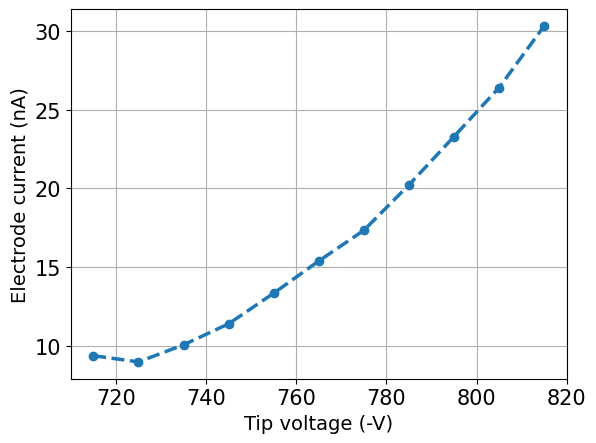

In [3]:
exp.V_tip = 800
# exp.max_I = 1 
calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=True, I_max=35e-9)

100%|███████████████████████████████████████████| 11/11 [01:01<00:00,  5.59s/it]


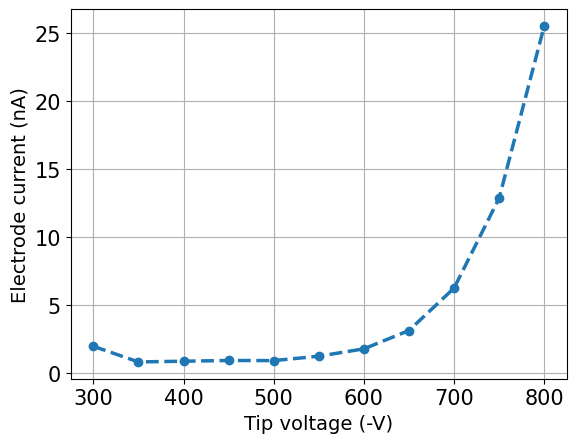

In [10]:
tip_Vsweep = sequences.TipVoltageSweepDifferential(saving_dir=exp.saving_dir, 
                                 V_start=300, V_stop=800, V_step=50, R=200e6, 
                                 N_avg=1, t_PSU_settle=2, t_meas_delay=0.2, 
                                 V_fixed=100, ch_sweep='neg', ch_fixed='pos',I_max=30e-9,
                                 FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Agilent)
file = tip_Vsweep.run_save()
plot_errbar(file['all_V'], np.mean(file['all_I'], axis=1)*1e9, yerr=np.std(file['all_I'], axis=1)*1e9, fmt='.--', 
            xlabel='Tip voltage (-V)', ylabel='Electrode current (nA)', label=f'Ring bias +100V')

In [16]:
all_Ex = [0.1]

for Ex in all_Ex:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-100, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.212e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=True)
    file = RF_sweep.run_save()
    # reset_tip_V(exp, V_pos=1200)

RID: 10380
voltages loaded


100%|███████████████████████████████████████████| 30/30 [16:25<00:00, 32.86s/it]


In [13]:
RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=P_detect, P_detect=P_detect, V_on=0, V_off=0, V_pos=0,
                                     t_load=0.1, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    
RF_sweep.set_parameters(Ex=0.25, U2=-0.4, background=True)
file = RF_sweep.run_save()

100%|███████████████████████████████████████████| 30/30 [01:27<00:00,  2.92s/it]


In [16]:
import random
# # all_P = [5]
# random.shuffle(all_P)
# print(all_P)
# exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
# time.sleep(5)
all_Ex = [0.5]
random.shuffle(all_Ex)
print(all_Ex)
for Ex in all_Ex:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=1200,
                                     t_load=20, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.4)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.4, background=True)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=1200)

[0.5]
RID: 10197
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


In [11]:
exp.V_tip

815.0

In [9]:
import random
# # all_P = [5]
# random.shuffle(all_P)
# print(all_P)
# exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
# time.sleep(5)
all_Ex = [-0.5, -0.3, 0, 0.3, 0.5]
random.shuffle(all_Ex)
print(all_Ex)
for Ex in all_Ex:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=450,
                                     t_load=30, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.4)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.4, background=False)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=450)

all_U2 = [-1, -0.7, -0.5, -0.4, -0.3]
for U2 in all_U2: 
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=5, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=450,
                                     t_load=30, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=450)

all_P_detect = [7.5,7,6,5,4,3]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=450,
                                     t_load=30, t_data=0.1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=10e3, N_avg=50, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.4)
    RF_sweep.set_parameters(Ex=0, U2=-0.4, background=False)
    file = RF_sweep.run_save()
    reset_tip_V(exp, V_pos=450)

exp.Valon.output_off()

[0, 0.3, -0.5, -0.3, 0.5]
RID: 10176
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


RID: 10177
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


RID: 10178
voltages loaded


...

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.58s/it]


RID: 10190
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


RID: 10191
voltages loaded


100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.56s/it]


In [11]:
exp.FEtip_PSU.ramp_down(0)

100%|███████████████████████████████████████████| 11/11 [01:01<00:00,  5.59s/it]


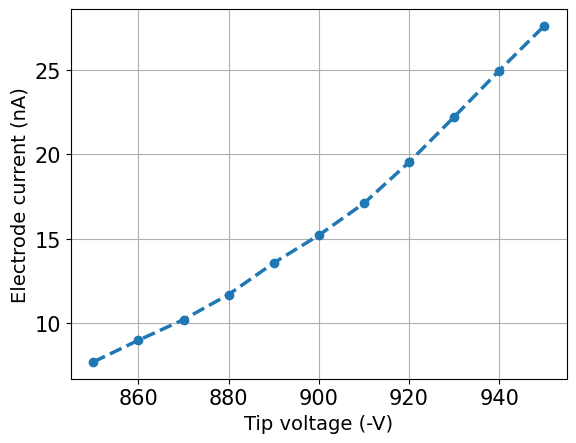

100%|███████████████████████████████████████████| 11/11 [01:01<00:00,  5.59s/it]


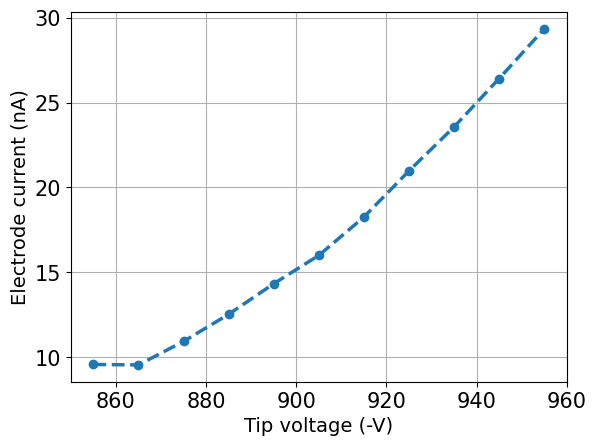

100%|███████████████████████████████████████████| 11/11 [01:01<00:00,  5.59s/it]


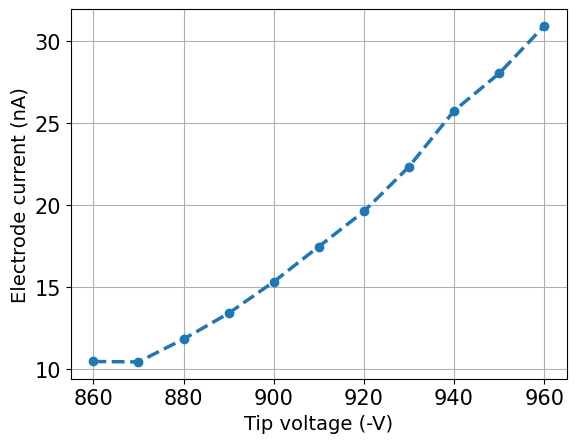

In [22]:
exp.V_tip = 950
calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=True, I_max=35e-9)

In [25]:
exp.Valon.output_off()

In [26]:
import random
all_P_detect = [1]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=8, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-200, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=False)
    file = RF_sweep.run_save()
    calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10425
voltages loaded


 55%|████████████████████████                    | 6/11 [00:39<00:32,  6.53s/it]

>>> Warning: Current 3.700027505e-08 exceeds maximum allowed 3.5e-08. Stopping sweep.


In [ ]:
import random
all_P_detect = [0.5,1,1.5]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=8, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-200, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=False)
    file = RF_sweep.run_save()
    calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

In [ ]:
RF_sweep = sequences.RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=100,
                                     t_load=20, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=False)
    calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)
    file = RF_sweep.run_save()

In [90]:
exp.Valon.set_power(12)

In [170]:
exp.Valon.set_power(5)
# exp.Valon.output_on()


In [152]:
exp.Valon.output_on()

In [169]:
while True: 
    exp.Valon.set_power(12) 
    time.sleep(20) 
    exp.Valon.set_power(5)
    time.sleep(3) 

KeyboardInterrupt: 

In [150]:
exp.Valon.output_off()

100%|███████████████████████████████████████████| 11/11 [01:01<00:00,  5.59s/it]


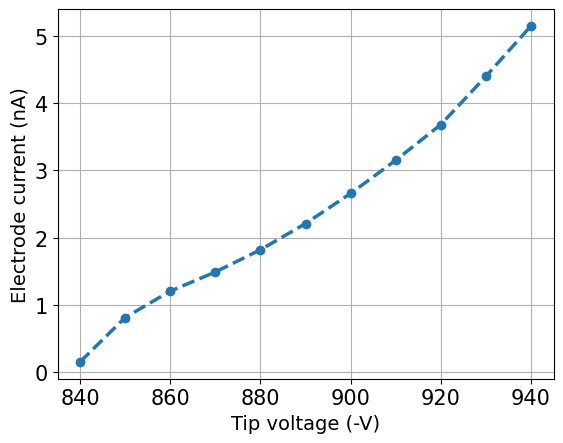

In [171]:
# exp.V_tip = 950
calibration.reset_tip_V(exp, tip_current=5, V_pos=100, show_plot=True, I_max=35e-9)

In [172]:
exp.FEtip_PSU.ramp_up(exp.V_tip)
exp.FEtip_PSU.ramp_up_ch(2,100)

In [163]:
exp.FEtip_PSU.ramp_down(0)
exp.FEtip_PSU.ramp_down_ch(2,0)

In [175]:
all_Ex = [0.1]
# random.shuffle(all_Ex)
# print(all_Ex)
for Ex in all_Ex:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=100,
                                     t_load=20, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.4)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.4, background=False)
    calibration.reset_tip_V(exp, tip_current=5, V_pos=100, show_plot=False, I_max=35e-9)
    file = RF_sweep.run_save()

RID: 10517
voltages loaded


100%|███████████████████████████████████████████| 30/30 [11:26<00:00, 22.87s/it]


In [35]:
beep_jupyter()

In [31]:
exp.V_tip

920.0

In [30]:
import random
all_P_detect = [5]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P, V_on=exp.V_tip, V_off=exp.V_tip-100, V_pos=100,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=False)
    file = RF_sweep.run_save()
    calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10430
voltages loaded


 91%|███████████████████████████████████████    | 10/11 [01:01<00:06,  6.15s/it]

>>> Warning: Current 3.508666855e-08 exceeds maximum allowed 3.5e-08. Stopping sweep.


In [40]:
exp.Valon.output_off()

In [39]:
import random
all_P_detect = [1]
for P in all_P_detect:
    RF_sweep = sequences.RFPowerSweepDifferentialNAcquisitionTipSwitched(saving_dir=exp.saving_dir, 
                                     P_load=8, P_detect=P, V_on=0, V_off=0, V_pos=0,
                                     t_load=30, t_data=1, t_rest=1,
                                     SSA_freq_center=176.310e6, SSA_freq_span=0.e6,
                                     SSA_RBW=1e3, N_avg=30, SSA_SWT=0.1,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0, U2=-0.7)
    RF_sweep.set_parameters(Ex=0, U2=-0.7, background=True)
    file = RF_sweep.run_save()
    # calibration.reset_tip_V(exp, tip_current=30, V_pos=100, show_plot=False, I_max=35e-9)

exp.Valon.output_off()

RID: 10420
voltages loaded


  0%|                                                    | 0/30 [00:23<?, ?it/s]


KeyboardInterrupt: 

In [29]:
beep_jupyter()

In [9]:
exp.DAC.set_multipoles(Ex=0.5, U2=-0.7)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.5, U2=-0.7, background=False)
file = RF_sweep.run_save()

RID: 10058
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.13s/it]


In [ ]:
RF_sweep = RFPowerConstSweepDifferential(
    saving_dir=exp.saving_dir,
    P_valon_hold=0,
    valon_settle=2, loading_time=0, measurement_time=300,
    P_min_dBm=6, P_max_dBm=4, steps=2,  
    V_on=exp.V_tip, V_off=exp.V_tip-300, V_pos=40,
    SSA_freq_center=176.31e6, SSA_freq_span=0,
    SSA_RBW=1e3, SSA_SWT=0.1,
    Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
    N_inner=1, N_outer=1, 
    display_progress='Pscan'
)

In [4]:
RF_sweep = RFPowerConstSweepDifferential(
    saving_dir=exp.saving_dir,
    P_valon_hold=0,
    valon_settle=2, loading_time=0, measurement_time=300,
    P_min_dBm=12, P_max_dBm=5, steps=2,  
    V_on=exp.V_tip, V_off=950, V_pos=40,
    SSA_freq_center=176.31e6, SSA_freq_span=0,
    SSA_RBW=1e3, SSA_SWT=0.1,
    Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
    N_inner=1, N_outer=1, 
    display_progress='Pscan'
)
for Ex in [-0.1, 0, 0.3, 0.5, 0.7, 1.5, 3]:
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=False)
    file = RF_sweep.run_save()

for U2 in [-1, -0.7, -0.4, 1]:
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
    
beep_jupyter()


RID: 10098
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.09s/it]


RID: 10099
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.05s/it]


RID: 10100
voltages loaded


...

>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.08s/it]


RID: 10107
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.08s/it]


RID: 10108
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.14s/it]


In [110]:
exp.FEtip_PSU.ramp_down_ch('pos', 0)

In [109]:
for U2 in [-1, -0.9, -0.8, -0.7]:
    RF_sweep = RFPowerConstSweepTipSwitched(
        saving_dir=exp.saving_dir,
        P_valon_hold=5,
        valon_settle=2, loading_time=0, measurement_time=30,
        P_min_dBm=12.45, P_max_dBm=7.12, steps=2,  
        V_on=850, V_off=500, V_pos=600,
        SSA_freq_center=176.2190e6, SSA_freq_span=0,
        SSA_RBW=1e3, SSA_SWT=0.1,
        Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
        N_inner=1, N_outer=1, 
        display_progress='Pscan'
    )
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
beep_jupyter()


RID: 10015
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.07s/it]


RID: 10016
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.06s/it]


RID: 10017
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.09s/it]


RID: 10018
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.11s/it]


In [ ]:
exp.Valon.output_off()